# Kalman Filterを用いた線形システムのパラメータ推定

Kalman Filterを用いて、線形システムのパラメータの推定を行う。



## 離散モデル

次の線形モデルの$m[k], D[k]$を測定値の$f[k], a[k], v[k]$から求めることを考える。

$$
f[k] = m[k] \ a[k] + D[k] \  v[k] + w[k]
$$

上式は、慣性 $m[n]$と、粘性 $D[n]$ による運動モデルである。そして、$w[n]$は測定値に含まれるノイズを表した観測雑音であり、平均$0$、分散$\sigma_w^2$の正規分布に従う。

ここでは加速度と速度の測定誤差は無視し、力の観測値に加法的な観測雑音が含まれると仮定する。

この仮定より、$m[n],D[n]$と加速度、速度を一定とした場合、上式の分散を取ると以下のようになる。

$$
\text{Var}\left[f[k] \right] = \text{Var} \left[m[k] \ a[k] + D[k] \  v[k] + w[k] \right] = \text{Var} \left[ w[k] \right] = \sigma_w^2
$$


## 推定モデル

推定すべきパラメータを${\theta}[k]$、 システムの応答値を$z[k]$、システムへの入力を$y[k]$とする。

$$
{\theta}[k] = \begin{bmatrix} m[k] \\ D[k] \end{bmatrix}, \quad z[k] = \begin{bmatrix} a[k] \\ v[k] \end{bmatrix} , \quad y[k] = f[k]
$$

すると、離散モデルは次の形式で記述できる。

$$
y[k] = {\theta}[k]^T z[k] + w [k]
$$

${\theta}[k]$は時変であるため、次のランダムウォークするウィナーモデルで表現することができる。<br>
$\eta[k]$は平均$0$、共分散行列$Q$の正規分布に従う。

$$
{\theta}[k+1] = {\theta}[k] + \eta [k]
$$

$Q=\text{diag}(q_m, q_D)$ であり、推定アルゴリズム中に用いる$m[k],D[k]$ の1step当たりのパラメータ変化の共分散である。

## Kalman Filterによる推定アルゴリズム

### 初期値を次のように設定する

- $\hat{\theta}[0] = \theta_0 \in \mathrm{R}^{2 \times 1}$
    - $\theta_0$は事前にある程度の値が分かればそれを設定する。
    - 事前情報が利用できない場合は $\theta_0 = 0$ とする。
- $P[0] = \text{diag}(\sigma_m^2, \sigma_D^2)$ (2 x 2 の対角行列)
    - $\sigma_m^2, \sigma_D^2$は各パラメータの初期推定誤差の分散
    - 事前情報が利用できない場合、ある程度の大きさに設定する($10^3 \mathrm{I}$など)

例えば事前情報が次である場合、

- 質量$m$ : 推定値 $5$ kg、誤差の標準偏差 $1$ kg
- 粘性$D$ : 推定値 $2$ Ns/m 、誤差の標準偏差 $0.5 Ns/m$

両者の誤差に相関がないと仮定すると、初期設定値は次のようになる。

$$
\hat{\theta}[0] = \begin{bmatrix} 5 \\ 2 \end{bmatrix}, \quad
P[0] = \begin{bmatrix} 1^2 & 0 \\ 0 &0.5^2 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 &0.25 \end{bmatrix}
$$

### アルゴリズム

各時刻で次の式を上から順番に計算していくことで、推定パラメータ$\hat{\theta}[k]$を求める。

$$
\begin{aligned}
P^{-}[k] &= P[k-1] + Q \\
\epsilon[k] &= y[k] - z[k]^T \hat{\theta}[k-1] \\
g[k] &= \frac{P^{-}[k] \ z[k]}{z[k]^T P^{-}[k] \ z[k] + \sigma_w^2} \\
\hat{\theta}[k] &= \hat{\theta}[k-1] + g[k] \epsilon[k] \\
P[k] &= (\mathrm{I} - g[k] z[k]^T)P^{-}[k]
\end{aligned}
$$

- $P[k]$ : 真値と推定値の誤差の共分散行列
- $P^{-}[k]$ 時刻$k$における誤差共分散行列の推定値 (2 x 2 の行列)
- $\epsilon[k]$ : 観測値と予測観測値の差(イノベーション)
- $g[k]$ : カルマンゲイン ( 2 x 1 の縦ベクトル)


### 推定に関する注意

$\hat{\theta}[k]$のパラメータをすべて推定するには、加速度と速度が常に同じ比例関係にならない運動が必要である。

常に同じ比例関係とは、時不変の比例係数$c$を使い$a[k]=c \ v[k]$のとなる運動である。これにより、計算が

$$
f[k] = (c m + D) v[k] + w[k]
$$

となり、$m$と$v$が区別できなくなる。

$a[k] = \dot{v}[k]$であるため、次のような速度であれば、$a[k] \neq c v[k]$ となる。

$$
v[k] = A \sin(\omega (\Delta t k))  \rightarrow a[k] = A \omega \cos(\omega (\Delta t k)) 
$$

## Pythonによる実装

実装では数値的な安定性を考慮して誤差の共分散行列の計算にはJoseph形式を用いる。

#### Josephi形式について

記述の簡略化のため、時刻を示す$[k]$を外して説明する。

観測モデルはパラメーターの真値($\theta$)と応答値、観測雑音$w$を用いて以下である。$R=\sigma_w^2$

$$
y = z^T \theta + w, \quad \mathbf{E}[w^2] = R
$$

推定パラメーターの更新式は以下である。この$\theta^{-}$は$\hat{\theta}[k-1]$のことである。

$$
\hat{\theta} = \hat{\theta}^{-} + g (y - z^T \hat{\theta}^{-})
$$

##### 更新後の推定誤差

更新前後の真値$\theta$と推定値$\hat{\theta}$の誤差を以下と定義する。

$$
e^{-} = \theta - \hat{\theta}^{-}, \quad e= \theta - \hat{\theta}
$$

イノベーションは以下となる。

$$
\epsilon = y - z^T \hat{\theta}^{-} = z^T \theta + w - z^T \hat{\theta}^{-} = z^T(\theta - \hat{\theta}^{-}) + w = z^T e^{-} + w
$$

よって、更新後の誤差は次で表せる。

$$
\begin{aligned}
e &= \theta - \hat{\theta} \\
&= \theta - \left( \hat{\theta}^{-} + g (y - z^T \hat{\theta}^{-}) \right) \\
&= \theta - \hat{\theta}^{-} - g (z^T e^{-} + w) \\
&= e^{-} - g z^T e^{-} - gw \\
&= (\boldsymbol{I} - g z^T) e^{-} - gw \\
\end{aligned}
$$

###### 更新後の推定誤差の共分散

$A=\boldsymbol{I} - g z^T$ とすると、$e=Ae^{-} - gw$となる。よって、共分散は次のようになる。

$$
\begin{aligned}
P=\mathbf{E}[{e}{e}^T] &= \mathbf{E}[ (Ae^{-} - gw)(Ae^{-} - gw)^T] \\
&= \mathbf{E}[Ae^{-}{e^{-}}^TA^T] - \mathbf{E}[Ae^{-}w^Tg] - \mathbf{E}[gw{e^{-}}^TA^T] + \mathbf{E}[gww^Tg^T]
\end{aligned}
$$

この中で$e^{-}$には推定パラメータの$\hat{\theta}$があり、この$\hat{\theta}$は観測雑音$w$を含んだ$y$で計算さるため、確率変数となる。

$z$は雑音を含まないとして仮定している。そしてカルマンゲイン$g$には$y$の情報を用いず、確定した$z, Q, R,P[0]$を用いた計算であるため、確定した値である。よって、$A$と$g$は期待値計算から外すことが出来る。

$$
\begin{aligned}
P=\mathbf{E}[{e}{e}^T] = A\mathbf{E}[e^{-}{e^{-}}^T]A^T - A\mathbf{E}[e^{-}w^T]g - g\mathbf{E}[w{e^{-}}^T]A^T + g\mathbf{E}[ww^T]g^T
\end{aligned}
$$

観測雑音$w$と更新前の誤差$e^{-}$が無相関であるなら、以下である。

$$
\mathbf{E}[e^{-}w^T]=\mathbf{E}[w{e^{-}}^T]=0
$$

また、次でもある。

$$
\mathbf{E}[e^{-}{e^{-}}^T] = P^{-}, \quad \mathbf{E}[ww^T]=R
$$

よって以下のJoseph形式が導出される。

$$
\begin{aligned}
P=\mathbf{E}[{e}{e}^T] = AP^{-}A^T + gRg^T = (\boldsymbol{I} - g z^T)P^{-}(\boldsymbol{I} - g z^T)^T + Rgg^T
\end{aligned}
$$



In [ ]:
import numpy as np

class KalmanFilter(object):

    def __init__(self,
                 initial_parameters:np.ndarray,
                 variance_of_initial_parameter_errors:np.ndarray,
                 variance_of_mesurement:float,
                 covariance_matrix_of_parameters:np.ndarray,
                 ):

        self.parameters = initial_parameters
        self.error_covariance_matrix = np.diag(variance_of_initial_parameter_errors)
        self.R = variance_of_mesurement
        self.Q = covariance_matrix_of_parameters

    def calculate_parameters(self,
                             y:float,
                             z:np.ndarray):
        
        P_pred =self.error_covariance_matrix + self.Q
        innovation = y - z @ self.parameters
        n = P_pred @ z
        d = z @ n + self.R
        gain = n / d
        self.parameters = self.parameters + gain * innovation

        I = np.eye(self.parameters.size)
        A = I - np.outer(gain,z) 
        self.error_covariance_matrix = (
            A @ P_pred @ A.T
            + self.R * np.outer(gain, gain)
        ) # 数値的な安定性を考慮してJoseph形式を用いる

        return self.parameters

        

### パラメータが固定されている場合

真の質量 m: 5.000 kg
推定した質量 m: 4.968 kg
真の粘性係数 D: 2.000 Ns/m
推定した粘性係数 D: 1.956 Ns/m


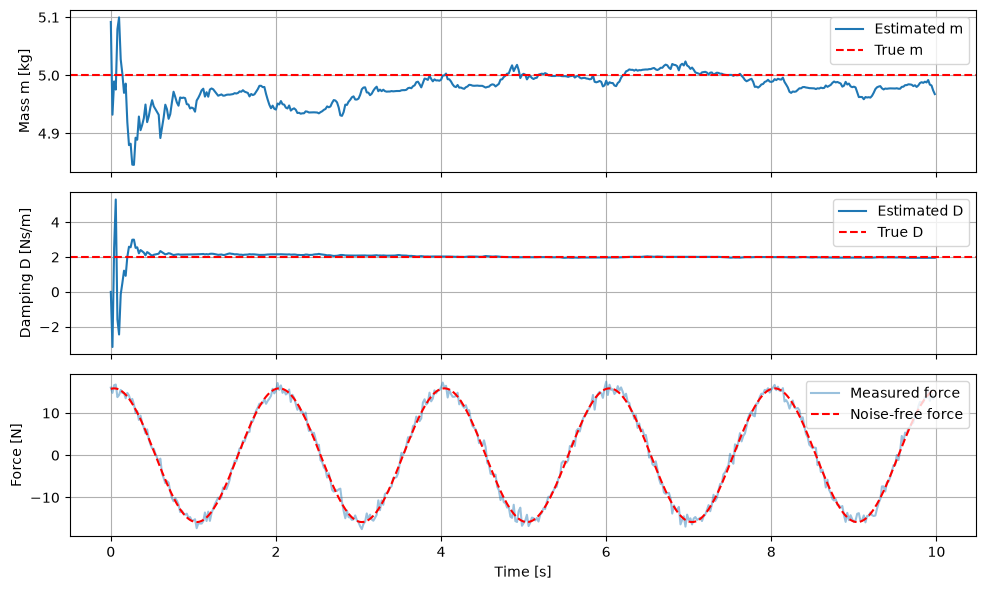

In [21]:
import matplotlib.pyplot as plt

# 再現可能なシミュレーション用の乱数
rng = np.random.default_rng(42)

# 真のパラメータ [質量 m, 粘性係数 D]
true_parameters = np.array([5.0, 2.0])

# 速度 v = A sin(ωt)、加速度 a = dv/dt
sample_count = 500
dt = 0.02
time = np.arange(sample_count) * dt
amplitude = 1.0
omega = 2.0 * np.pi * 0.5
velocity = amplitude * np.sin(omega * time)
acceleration = amplitude * omega * np.cos(omega * time)

# 観測式: force = m * acceleration + D * velocity + measurement_noise
z_data = np.column_stack((acceleration, velocity))
measurement_noise_std = 1.0
measurement_noise = rng.normal(0.0, measurement_noise_std, sample_count)
force_true = z_data @ true_parameters
force_measured = force_true + measurement_noise

# フィルタの初期値
initial_parameters = np.array([0.0, 0.0])
initial_parameter_variances = np.array([100.0, 100.0])
measurement_variance = measurement_noise_std**2
parameter_process_covariance = np.diag([1e-5, 1e-5])

kalman_filter = KalmanFilter(
    initial_parameters=initial_parameters,
    variance_of_initial_parameter_errors=initial_parameter_variances,
    variance_of_mesurement=measurement_variance,
    covariance_matrix_of_parameters=parameter_process_covariance,
)

estimated_parameters = np.zeros((sample_count, 2))
for k in range(sample_count):
    estimated_parameters[k] = kalman_filter.calculate_parameters(
        y=force_measured[k],
        z=z_data[k],
    )

print(f"真の質量 m: {true_parameters[0]:.3f} kg")
print(f"推定した質量 m: {estimated_parameters[-1, 0]:.3f} kg")
print(f"真の粘性係数 D: {true_parameters[1]:.3f} Ns/m")
print(f"推定した粘性係数 D: {estimated_parameters[-1, 1]:.3f} Ns/m")

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(time, estimated_parameters[:, 0], label="Estimated m")
axes[0].axhline(true_parameters[0], color="red", linestyle="--", label="True m")
axes[0].set_ylabel("Mass m [kg]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time, estimated_parameters[:, 1], label="Estimated D")
axes[1].axhline(true_parameters[1], color="red", linestyle="--", label="True D")
axes[1].set_ylabel("Damping D [Ns/m]")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time, force_measured, alpha=0.45, label="Measured force")
axes[2].plot(time, force_true, color="red", linestyle="--", label="Noise-free force")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Force [N]")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


#### パラメータが時間変化する場合

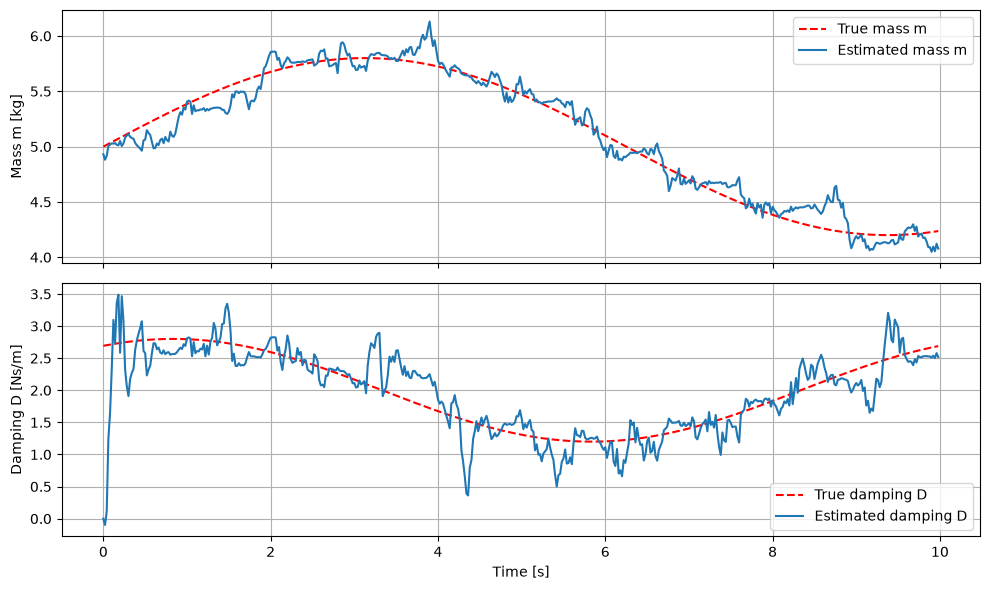

In [23]:
# 時間変化するパラメータを推定するシミュレーション

# 真の質量 m と粘性係数 D がゆっくり変化するケース
true_parameters_varying = np.column_stack((
    5.0 + 0.8 * np.sin(2.0 * np.pi * 0.08 * time),
    2.0 + 0.8 * np.sin(2.0 * np.pi * 0.1 * time + np.pi / 3.0),
))

# 時変パラメータを使って力を計算し、観測ノイズを加える
force_true_varying = np.sum(z_data * true_parameters_varying, axis=1)
measurement_noise_varying = rng.normal(0.0, measurement_noise_std, sample_count)
force_measured_varying = force_true_varying + measurement_noise_varying

# パラメータが変化するため、定数パラメータの例より Q を大きくする
kalman_filter_varying = KalmanFilter(
    initial_parameters=np.array([0.0, 0.0]), # theta[0]
    variance_of_initial_parameter_errors=np.array([1e1, 1e1]), # P[0]
    variance_of_mesurement=measurement_variance, # sigma_w
    covariance_matrix_of_parameters=np.diag([2e-3, 2e-2]), # Q
)

estimated_parameters_varying = np.zeros((sample_count, 2))
for k in range(sample_count):
    estimated_parameters_varying[k] = kalman_filter_varying.calculate_parameters(
        y=force_measured_varying[k],
        z=z_data[k],
    )

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(time, true_parameters_varying[:, 0], "r--", label="True mass m")
axes[0].plot(time, estimated_parameters_varying[:, 0], label="Estimated mass m")
axes[0].set_ylabel("Mass m [kg]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time, true_parameters_varying[:, 1], "r--", label="True damping D")
axes[1].plot(time, estimated_parameters_varying[:, 1], label="Estimated damping D")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Damping D [Ns/m]")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### パラメータがステップ的に変化する場合

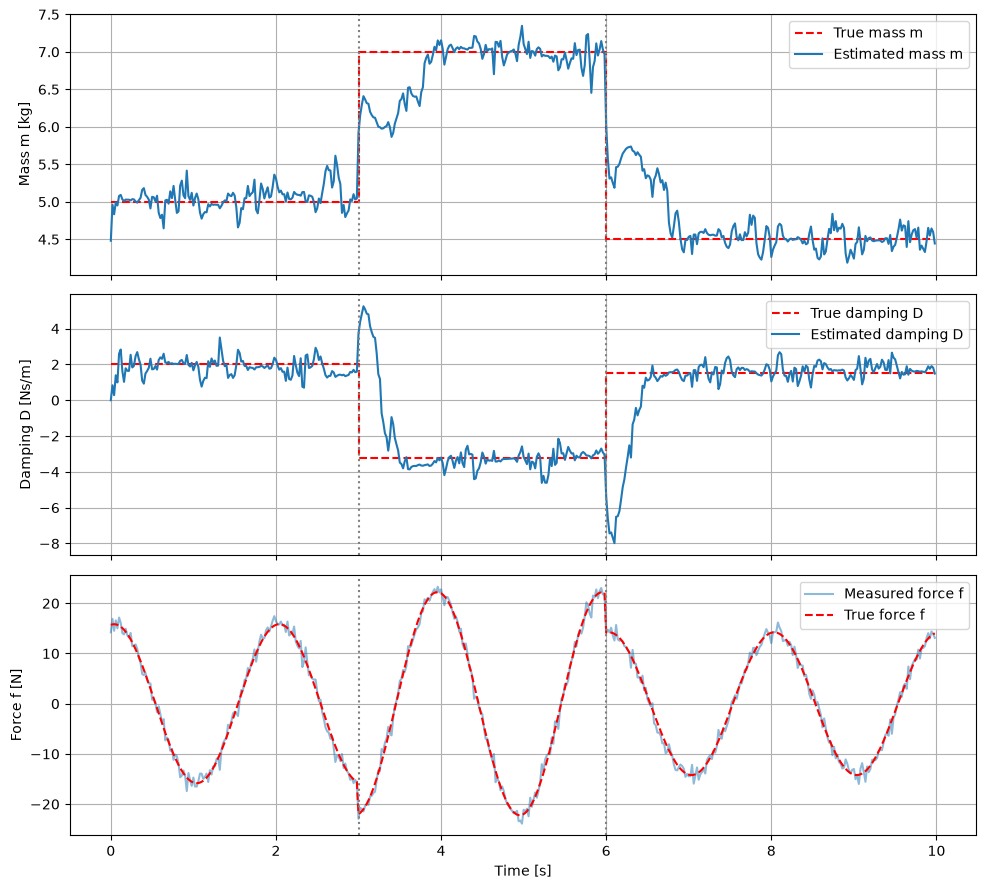

In [30]:
# m と D がそれぞれ2回ステップ変化するシミュレーション

step_time_1 = 3.0
step_time_2 = 6.0

# m: 5 -> 7 -> 4.5 kg、D: 2 -> 3.2 -> 1.5 Ns/m
true_mass_step = np.where(
    time < step_time_1,
    5.0,
    np.where(time < step_time_2, 7.0, 4.5),
)
true_damping_step = np.where(
    time < step_time_1,
    2.0,
    np.where(time < step_time_2, -3.2, 1.5),
)
true_parameters_step = np.column_stack((true_mass_step, true_damping_step))

# ステップ状の真値から力を生成し、観測ノイズを加える
force_true_step = np.sum(z_data * true_parameters_step, axis=1)
measurement_noise_step = rng.normal(0.0, measurement_noise_std, sample_count)
force_measured_step = force_true_step + measurement_noise_step

# Q を設定し、急なパラメータ変化に追従させる
kalman_filter_step = KalmanFilter(
    initial_parameters=np.array([0.0, 0.0]),
    variance_of_initial_parameter_errors=np.array([10.0, 10.0]),
    variance_of_mesurement=measurement_variance,
    covariance_matrix_of_parameters=np.diag([2e-2, 2e-1]),
)

estimated_parameters_step = np.zeros((sample_count, 2))
for k in range(sample_count):
    estimated_parameters_step[k] = kalman_filter_step.calculate_parameters(
        y=force_measured_step[k],
        z=z_data[k],
    )

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].step(time, true_mass_step, where="post", color="red", linestyle="--", label="True mass m")
axes[0].plot(time, estimated_parameters_step[:, 0], label="Estimated mass m")
axes[0].set_ylabel("Mass m [kg]")
axes[0].legend()
axes[0].grid(True)

axes[1].step(time, true_damping_step, where="post", color="red", linestyle="--", label="True damping D")
axes[1].plot(time, estimated_parameters_step[:, 1], label="Estimated damping D")
axes[1].set_ylabel("Damping D [Ns/m]")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time, force_measured_step, alpha=0.5, label="Measured force f")
axes[2].plot(time, force_true_step, color="red", linestyle="--", label="True force f")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Force f [N]")
axes[2].legend()
axes[2].grid(True)

for ax in axes:
    ax.axvline(step_time_1, color="gray", linestyle=":")
    ax.axvline(step_time_2, color="gray", linestyle=":")

plt.tight_layout()
plt.show()
